In [35]:
import pandas as pd
from IPython.display import display
import pandasql as psql

# Load the main dataset
crime_data = pd.read_csv('../data/raw/crimeData.csv')

# Convert DATE OCC to datetime and format it to match the FullDate format in date_dim
crime_data['DATE OCC'] = pd.to_datetime(crime_data['DATE OCC']).dt.date

# Replace blank values in Premis Cd with 'Unknown'
crime_data['Premis Cd'] = crime_data['Premis Cd'].replace('', 'Unknown')

# Convert Premis Cd to string to match the type of premiseCode in premise_dim
crime_data['Premis Cd'] = crime_data['Premis Cd'].astype(str)

# Load the cleaned dimension tables
victim_dim = pd.read_excel('../data/dimensions/victimDimFinal.xlsx')
date_dim = pd.read_excel('../data/dimensions/date_Final.xlsx')
time_dim = pd.read_excel('../data/dimensions/time_finalnajd.xlsx')
premise_dim = pd.read_excel('../data/dimensions/premiseData.xlsx')
area_dim = pd.read_excel('../data/dimensions/Area_Dim_with_Lat_Long.xlsx')
crimetype_dim = pd.read_excel('../data/dimensions/Crime_Type_Dim.xlsx')
investigationstatus_dim = pd.read_excel('../data/dimensions/Investigation_Stat_Dim.xlsx')
location_dim = pd.read_excel('../data/dimensions/location_dimrevised.xlsx')

# Ensure FullDate in date_dim is also of type date
date_dim['FullDate'] = pd.to_datetime(date_dim['FullDate']).dt.date

# Convert premiseCode in premise_dim to string to match the type of Premis Cd in crime_data
premise_dim['premiseCode'] = premise_dim['premiseCode'].astype(str)

# Replace 'Unknown' values in premise_dim with a consistent value
premise_dim['premiseCode'] = premise_dim['premiseCode'].replace('Unknown', 'Unknown')

# Merge the main dataset with the dimension tables to create the fact table using full outer join
fact_table = crime_data.merge(victim_dim, left_on=['Vict Age', 'Vict Sex', 'Vict Descent'], right_on=['Vict Age', 'Vict Sex', 'Vict Descent'], how='outer') \
                       .merge(date_dim, left_on='DATE OCC', right_on='FullDate', how='outer') \
                       .merge(area_dim, left_on='AREA', right_on='areaCode', how='outer') \
                       .merge(crimetype_dim, left_on='Crm Cd', right_on='crimeCode', how='outer') \
                       .merge(investigationstatus_dim, left_on='Status', right_on='Status', how='outer') \
                       .merge(location_dim, left_on='LOCATION', right_on='location', how='outer') \
                       .merge(premise_dim, left_on='Premis Cd', right_on='premiseCode', how='outer') \
                       .merge(time_dim, left_on='TIME OCC', right_on='timeOcc', how='outer')

# Convert IDs to integers and handle null values
fact_table['victimID'] = fact_table['victimID'].fillna(0).astype(int)
fact_table['premise_id'] = fact_table['premise_id'].fillna(0).astype(int)
fact_table['time_id'] = fact_table['time_id'].fillna(0).astype(int)
fact_table['investigationStatusId'] = fact_table['investigationStatusId'].fillna(0).astype(int)
fact_table['locationID'] = fact_table['locationID'].fillna(0).astype(int)

# Fill victimID with a placeholder value to ensure all rows are counted
fact_table['victimID'] = fact_table['victimID'].replace(0, 0)

# create measure 1 (crimeperdemographCOunt)
fact_table['crimePerDemographCount'] = fact_table.groupby(['victimID']).cumcount() + 1

# create measure 2 (LocationCrimeDemographicsCount)
fact_table['LocationCrimeDemographicsCount'] = fact_table.groupby(['victimID','locationID']).cumcount() + 1

# only needed columns
fact_table = fact_table[['DR_NO', 'victimID', 'dateID', 'area_id', 'crimeType_id', 'investigationStatusId', 'locationID', 'premise_id', 'time_id', 'crimePerDemographCount', 'LocationCrimeDemographicsCount']]

#remove dups
fact_table = fact_table.drop_duplicates(subset=['DR_NO'])

#display first 15
display(fact_table.head(25))



C:\Users\Ivan Jayme\AppData\Local\Temp\ipykernel_32876\1972873124.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_data['DATE OCC'] = pd.to_datetime(crime_data['DATE OCC']).dt.date
C:\Users\Ivan Jayme\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,DR_NO,victimID,dateID,area_id,crimeType_id,investigationStatusId,locationID,premise_id,time_id,crimePerDemographCount,LocationCrimeDemographicsCount
0,230808190.0,1850,20230412.0,8.0,80.0,2,43741,1,1,1,1
1,221409131.0,0,20220410.0,14.0,57.0,2,4667,1,1,1,1
2,201409734.0,0,20200415.0,14.0,29.0,2,11353,1,1,2,1
3,221416648.0,0,20220718.0,14.0,57.0,2,4275,1,1,3,1
4,241406063.0,0,20230825.0,14.0,57.0,2,4275,1,1,4,2
5,241104299.0,0,20231101.0,11.0,29.0,2,41352,1,1,5,1
6,202008541.0,0,20200413.0,20.0,57.0,2,18672,1,1,6,1
7,220213833.0,1674,20220725.0,2.0,40.0,1,19493,1,1,1,1
8,231410880.0,4353,20230517.0,14.0,80.0,2,20121,1,1,1,1
9,241107407.0,0,20240409.0,11.0,29.0,2,29286,1,1,7,1


In [ ]:
import pandas as pd
from ipyleaflet import Map, Heatmap
from ipywidgets import widgets, interact

# Load the crime data and area dimension data
crime_data = pd.read_csv('../data/raw/crimeData.csv')
area_dim = pd.read_excel('../data/dimensions/Area_Dim_with_Lat_Long.xlsx')

# Ensure that the AREA column in crime_data is of type object (string)
crime_data['AREA NAME'] = crime_data['AREA NAME'].astype(str)

# Ensure that the areaName column in area_dim is of type object (string)
area_dim['areaName'] = area_dim['areaName'].astype(str)

# Debugging: Check unique values in AREA NAME and areaName columns
print("Unique AREA NAME values in crime_data:", crime_data['AREA NAME'].unique())
print("Unique areaName values in area_dim:", area_dim['areaName'].unique())

# Merge the crime data with the area dimension data to get latitude and longitude
merged_data = pd.merge(crime_data, area_dim, left_on='AREA NAME', right_on='areaName')

# Debugging: Check the contents of the merged_data DataFrame
print("Merged Data Columns:", merged_data.columns)
print("Merged Data Sample:", merged_data.head())

# Create a base map centered on Los Angeles
m = Map(center=(34.0522, -118.2437), zoom=10)

# Function to update the heatmap based on the selected descent
def update_heatmap(descent):
    # Filter the data based on the selected descent
    filtered_data = merged_data[merged_data['Vict Descent'] == descent]
    
    # Create a list of locations with their respective latitude and longitude
    heat_data = [[row['latitude'], row['longitude']] for index, row in filtered_data.iterrows()]
    
    # Create the heatmap layer
    heatmap = Heatmap(locations=heat_data, radius=15, blur=10, max_zoom=1, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'})
    
    # Clear the existing layers and add the new heatmap layer
    m.layers = [heatmap]

# Ensure the column name is correct
if 'Vict_Descent' in merged_data.columns:
    descent_column = 'Vict_Descent'
elif 'Vict Descent' in merged_data.columns:
    descent_column = 'Vict Descent'
else:
    raise ValueError("Victim descent column not found in merged data")

# Create a dropdown menu for selecting the descent
descent_dropdown = widgets.Dropdown(
    options=merged_data[descent_column].unique(),
    description='Descent:',
    value=merged_data[descent_column].unique()[0]
)

# Create an interactive widget to update the heatmap based on the selected descent
interact(update_heatmap, descent=descent_dropdown)

# Display the map
m

Unique AREA NAME values in crime_data: ['Wilshire' 'Central' 'Southwest' 'Van Nuys' 'Hollywood' 'Southeast'
 'Newton' 'Mission' 'Rampart' 'West Valley' 'West LA' 'Olympic'
 'Hollenbeck' 'Topanga' 'Northeast' '77th Street' 'Pacific' 'N Hollywood'
 'Harbor' 'Foothill' 'Devonshire']
Unique areaName values in area_dim: ['Central' 'Rampart' 'Southwest' 'Hollenbeck' 'Harbor' 'Hollywood'
 'Wilshire' 'West LA' 'Van Nuys' 'West Valley' 'Northeast' '77th Street'
 'Newton' 'Pacific' 'N Hollywood' 'Foothill' 'Devonshire' 'Southeast'
 'Mission' 'Olympic' 'Topanga']
Merged Data Columns: Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON', 'area_id', 'areaCode', 'areaName

interactive(children=(Dropdown(description='Descent:', options=('O', 'X', 'H', 'B', 'W', nan, 'A', 'K', 'C', '…

Map(center=[34.0522, -118.2437], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

TraitError: Invalid selection: value not found

TraitError: Invalid selection: value not found

In [71]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from ipywidgets import widgets, interact

# Load the crime data and area dimension data
crime_data = pd.read_csv('../data/raw/crimeData.csv')
area_dim = pd.read_excel('../data/dimensions/Area_Dim_with_Lat_Long.xlsx')

# Ensure that the AREA NAME column in crime_data is of type object (string)
crime_data['AREA NAME'] = crime_data['AREA NAME'].astype(str)

# Ensure that the areaName column in area_dim is of type object (string)
area_dim['areaName'] = area_dim['areaName'].astype(str)

# Merge the crime data with the area dimension data to get latitude and longitude
merged_data = pd.merge(crime_data, area_dim, left_on='AREA NAME', right_on='areaName')

# Function to update the heatmap based on the selected descent
def update_heatmap(descent):
    # Filter the data based on the selected descent
    filtered_data = merged_data[merged_data['Vict Descent'] == descent]
    
    # Group by latitude and longitude to get the incident count for each location
    grouped_data = filtered_data.groupby(['latitude', 'longitude', 'areaName']).size().reset_index(name='incident_count')
    
    # Create a list of locations with their respective latitude, longitude, and incident count
    heat_data = [[row['latitude'], row['longitude'], row['incident_count']] for index, row in grouped_data.iterrows()]
    
    # Create a base map centered on Los Angeles
    m = folium.Map(location=[34.0522, -118.2437], zoom_start=10)
    
    # Add the heatmap layer with weights
    HeatMap(heat_data, radius=45, blur=25, max_zoom=1).add_to(m)
    
    # Add CircleMarkers with tooltips for each location
    for index, row in grouped_data.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=5,
            color='grey',
            fill=True,
            fill_color='black',
            fill_opacity=0.2,
            tooltip=f"{row['areaName']}: {row['incident_count']} incidents"
        ).add_to(m)
    
    m.save('Gwapo.html')
    # Display the map
    return m

# Ensure the column name is correct
if 'Vict_Descent' in merged_data.columns:
    descent_column = 'Vict_Descent'
elif 'Vict Descent' in merged_data.columns:
    descent_column = 'Vict Descent'
else:
    raise ValueError("Victim descent column not found in merged data")

# Create a dropdown menu for selecting the descent
descent_dropdown = widgets.Dropdown(
    options=merged_data[descent_column].unique(),
    description='Descent:',
    value=merged_data[descent_column].unique()[0]
)

# Create an interactive widget to update the heatmap based on the selected descent
interact(update_heatmap, descent=descent_dropdown)




interactive(children=(Dropdown(description='Descent:', options=('O', 'X', 'H', 'B', 'W', nan, 'A', 'K', 'C', '…

<function __main__.update_heatmap(descent)>

In [72]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Load the crime data and area dimension data
crime_data = pd.read_csv('../data/raw/crimeData.csv')
area_dim = pd.read_excel('../data/dimensions/Area_Dim_with_Lat_Long.xlsx')

# Ensure that the AREA NAME column in crime_data is of type object (string)
crime_data['AREA NAME'] = crime_data['AREA NAME'].astype(str)

# Ensure that the areaName column in area_dim is of type object (string)
area_dim['areaName'] = area_dim['areaName'].astype(str)

# Merge the crime data with the area dimension data to get latitude and longitude
merged_data = pd.merge(crime_data, area_dim, left_on='AREA NAME', right_on='areaName')

# Filter the data for victim descent 'H'
filtered_data = merged_data[merged_data['Vict Descent'] == 'H']

# Group by latitude and longitude to get the incident count for each location
grouped_data = filtered_data.groupby(['latitude', 'longitude', 'areaName']).size().reset_index(name='incident_count')

# Create a list of locations with their respective latitude, longitude, and incident count
heat_data = [[row['latitude'], row['longitude'], row['incident_count']] for index, row in grouped_data.iterrows()]

# Create a base map centered on Los Angeles
m = folium.Map(location=[34.0522, -118.2437], zoom_start=10)

# Add the heatmap layer with weights
HeatMap(heat_data, radius=45, blur=25, max_zoom=1).add_to(m)

# Add CircleMarkers with tooltips for each location
for index, row in grouped_data.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='grey',
        fill=True,
        fill_color='black',
        fill_opacity=0.2,
        tooltip=f"{row['areaName']}: {row['incident_count']} incidents"
    ).add_to(m)

# Save the map to an HTML file
m.save('victim_descent_H_heatmap.html')

# Display the map
m

In [75]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Load the crime data and area dimension data
crime_data = pd.read_csv('../data/raw/crimeData.csv')
area_dim = pd.read_excel('../data/dimensions/Area_Dim_with_Lat_Long.xlsx')

# Ensure that the AREA NAME column in crime_data is of type object (string)
crime_data['AREA NAME'] = crime_data['AREA NAME'].astype(str)

# Ensure that the areaName column in area_dim is of type object (string)
area_dim['areaName'] = area_dim['areaName'].astype(str)

# Merge the crime data with the area dimension data to get latitude and longitude
merged_data = pd.merge(crime_data, area_dim, left_on='AREA NAME', right_on='areaName')

# Filter the data for victim descent 'H'
filtered_data = merged_data[merged_data['Vict Descent'] == 'F']

# Group by latitude and longitude to get the incident count for each location
grouped_data = filtered_data.groupby(['latitude', 'longitude', 'areaName']).size().reset_index(name='incident_count')

# Create a list of locations with their respective latitude, longitude, and incident count
heat_data = [[row['latitude'], row['longitude'], row['incident_count']] for index, row in grouped_data.iterrows()]

# Create a base map centered on Los Angeles
m = folium.Map(location=[34.0522, -118.2437], zoom_start=10)

# Add the heatmap layer with weights
HeatMap(heat_data, radius=45, blur=25, max_zoom=1).add_to(m)

# Add CircleMarkers with tooltips for each location
for index, row in grouped_data.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='grey',
        fill=True,
        fill_color='black',
        fill_opacity=0.2,
        tooltip=f"{row['areaName']}: {row['incident_count']} incidents"
    ).add_to(m)

# Save the map to an HTML file
m.save('victim_descent_F_heatmap.html')

# Display the map
m

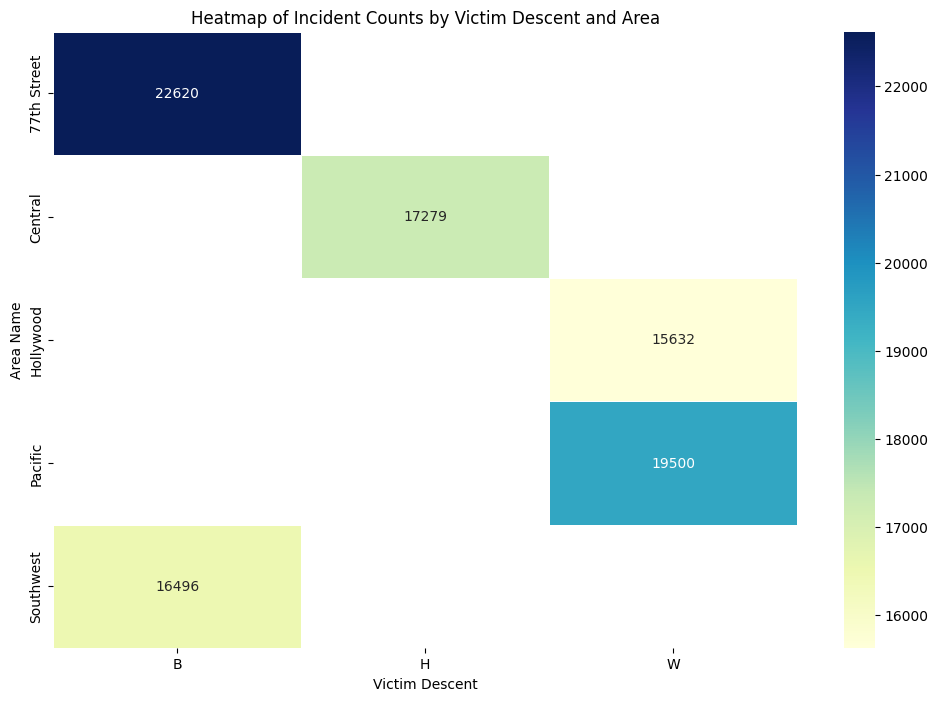

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dervied data
data = {
    'Vict_Descent': ['B', 'W', 'H', 'B', 'W'],
    'areaName': ['77th Street', 'Pacific', 'Central', 'Southwest', 'Hollywood'],
    'incidentCount': [22620, 19500, 17279, 16496, 15632]
}

df = pd.DataFrame(data)


heatmap_data = df.pivot_table(index='areaName', columns='Vict_Descent', values='incidentCount')

#heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap of Incident Counts by Victim Descent and Area')
plt.xlabel('Victim Descent')
plt.ylabel('Area Name')
plt.show()

In [1]:
import plotly.express as px
import pandas as pd

#derived data
df = pd.DataFrame({
    "Age Group": ["0-2", "3-5", "6-12", "13-18", "19-29", "30-44", "45-59", "60-74", "75-89", "90-100"],
    "Average Age": [0, 3, 9, 16, 24, 35, 51, 64, 78, 96],
    "Victim Count": [395, 14, 60, 381, 6018, 6210, 3195, 902, 86, 18]
})

# Normalize the Victim Count values to a range [0, 1]
df['Normalized Victim Count'] = (df['Victim Count'] - df['Victim Count'].min()) / (df['Victim Count'].max() - df['Victim Count'].min())

#choose min and max size of circles
min_size = 1
max_size = 60
df['Scaled Victim Count'] = df['Normalized Victim Count'] * (max_size - min_size) + min_size

#scatterplot
fig = px.scatter(
    df, x="Age Group", y="Average Age", size="Scaled Victim Count",
    title="Average Age by Age Group in Central (Descent: Hispanic)",
    size_max=max_size,  
    hover_data={"Victim Count": True}
)


fig.show()

#export
fig.write_html("average_age_by_the_mostdangerouesarea_descent_H6.html")

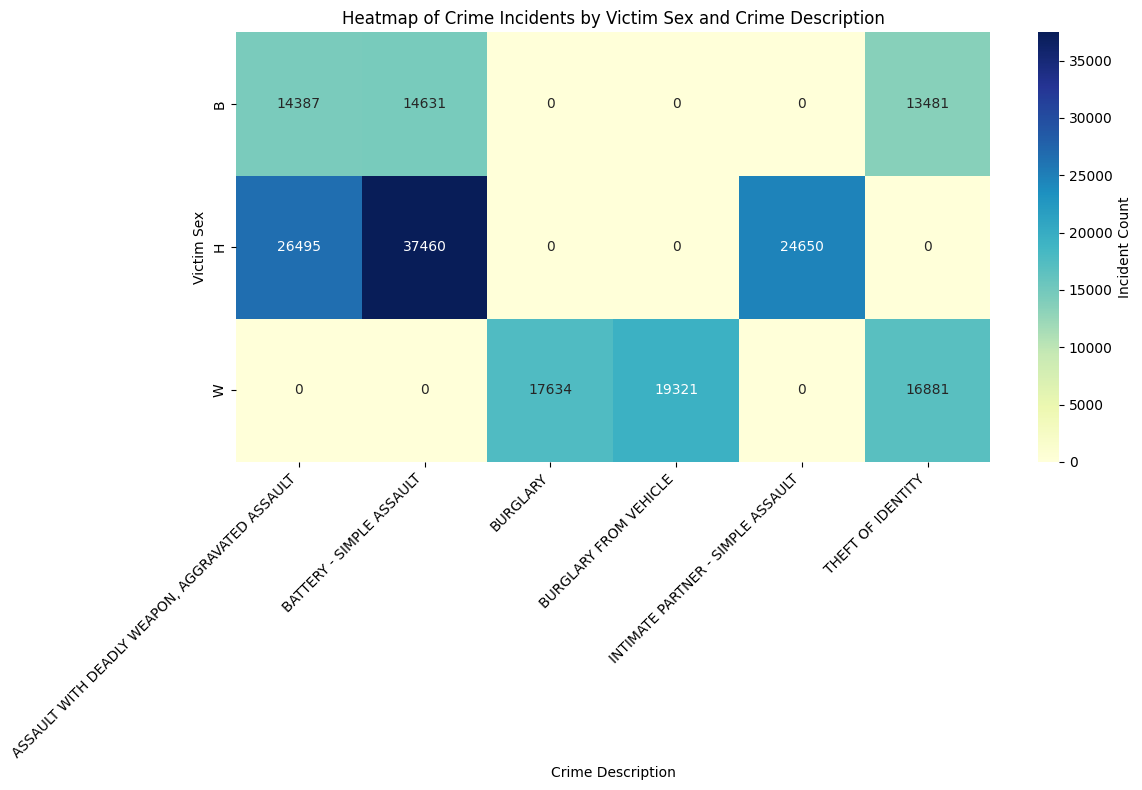

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# sql data
data = {
    'Vict_Sex': ['B', 'B', 'B', 'H', 'H', 'H', 'W', 'W', 'W'],
    'Crime_Code': ['624', '230', '354', '624', '230', '626', '330', '310', '354'],
    'Crime_Desc': [
        'BATTERY - SIMPLE ASSAULT', 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'THEFT OF IDENTITY',
        'BATTERY - SIMPLE ASSAULT', 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'INTIMATE PARTNER - SIMPLE ASSAULT',
        'BURGLARY FROM VEHICLE', 'BURGLARY', 'THEFT OF IDENTITY'
    ],
    'Incident_Count': [14631, 14387, 13481, 37460, 26495, 24650, 19321, 17634, 16881]
}


df = pd.DataFrame(data)

pivot_df = df.pivot_table(index='Vict_Sex', columns='Crime_Desc', values='Incident_Count', aggfunc='sum', fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt='g', cbar_kws={'label': 'Incident Count'})
plt.title('Heatmap of Crime Incidents by Victim Sex and Crime Description')
plt.xlabel('Crime Description')
plt.ylabel('Victim Sex')
plt.xticks(rotation=45, ha='right')  # Rotate column labels for better readability
plt.tight_layout()
plt.show()

In [2]:
import plotly.express as px
import pandas as pd

# Derived data
df = pd.DataFrame({
    "Age Group": ["0-2", "3-5", "6-12", "13-18", "19-29", "30-44", "45-59", "60-74", "75-89", "90-100"],
    "Average Age": [0, 3, 9, 16, 25, 35, 52, 64, 78, 96],
    "Victim Count": [166, 19, 28, 154, 3341, 5165, 2824, 1440, 72, 12]
})

# Normalize the Victim Count values to a range [0, 1]
df['Normalized Victim Count'] = (df['Victim Count'] - df['Victim Count'].min()) / (df['Victim Count'].max() - df['Victim Count'].min())

# Choose min and max size of circles
min_size = 1
max_size = 60
df['Scaled Victim Count'] = df['Normalized Victim Count'] * (max_size - min_size) + min_size

# Scatter plot
fig = px.scatter(
    df, x="Age Group", y="Average Age", size="Scaled Victim Count",
    title="Average Age by Age Group in Central (Descent: Black)",
    size_max=max_size,  
    hover_data={"Victim Count": True}
)

fig.show()

# Export
fig.write_html("average_age_by_the_mostdangerouesarea_descent_B.html")

In [6]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Create the DataFrame with the provided data
df = pd.DataFrame({
    "areaName": ["77th Street", "Pacific", "Central", "Southeast", "Southwest", "Hollywood", "Newton", "West LA", "Wilshire", "N Hollywood", "Olympic", "Rampart", "Northeast", "Van Nuys", "Harbor", "Hollenbeck", "Devonshire", "Mission", "Topanga", "West Valley", "Foothill"],
    "latitude": [33.9705293352152, 34.0465519518287, 34.0692172511457, 33.8852338058933, 34.0102736657445, 34.0907661732148, 34.0093775930857, 34.0439667897427, 34.0642122672302, 34.1865393009789, 34.0453673225847, 34.070352851515, 34.104844818528, 34.2013745199537, 33.7899563156081, 34.0439635874667, 34.2573449157599, 34.2705321211024, 34.0919001517263, 34.0783542856634, 34.2803281375687],
    "longitude": [-118.277510032245, -118.546498596709, -118.323961770567, -118.160106040571, -118.331121588879, -118.326700300499, -118.275491961043, -118.431843875951, -118.37177394309, -118.387796053347, -118.315071187471, -118.284299347918, -118.202248307969, -118.46611131084, -118.297536098266, -118.211442687252, -118.53170381311, -118.458437138528, -118.601759208101, -118.13028017221, -118.413993590625],
    "Year": [2020] * 21,
    "unresolved_count": [9901, 9490, 9098, 8701, 8659, 8271, 8189, 7522, 7326, 7225, 7072, 6756, 6619, 6346, 6242, 6065, 6013, 5924, 5724, 5599, 5142]
})

# Create a list of locations with their respective latitude, longitude, and unresolved count
heat_data = [[row['latitude'], row['longitude'], row['unresolved_count']] for index, row in df.iterrows()]

# Create a base map centered on Los Angeles
m = folium.Map(location=[34.0522, -118.2437], zoom_start=10)

# Add the heatmap layer with weights
HeatMap(heat_data, radius=45, blur=25, max_zoom=1).add_to(m)

# Add CircleMarkers with tooltips for each location
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='grey',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        tooltip=folium.Tooltip(f"{row['areaName']}: {row['unresolved_count']} unresolved cases")
    ).add_to(m)

m
# Save the map as an HTML file
# m.save('unresolved_cases_heatmap2020.html')



In [8]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Create the DataFrame with the provided 2021 data
df = pd.DataFrame({
    "areaName": ["Pacific", "Central", "Hollywood", "77th Street", "Southwest", "Southeast", "West LA", "Olympic", "N Hollywood", "Wilshire", "Newton", "Northeast", "Rampart", "Van Nuys", "Harbor", "Devonshire", "Topanga", "Hollenbeck", "West Valley", "Mission", "Foothill"],
    "latitude": [34.0465519518287, 34.0692172511457, 34.0907661732148, 33.9705293352152, 34.0102736657445, 33.8852338058933, 34.0439667897427, 34.0453673225847, 34.1865393009789, 34.0642122672302, 34.0093775930857, 34.104844818528, 34.070352851515, 34.2013745199537, 33.7899563156081, 34.2573449157599, 34.0919001517263, 34.0439635874667, 34.0783542856634, 34.2705321211024, 34.2803281375687],
    "longitude": [-118.546498596709, -118.323961770567, -118.326700300499, -118.277510032245, -118.331121588879, -118.160106040571, -118.431843875951, -118.315071187471, -118.387796053347, -118.37177394309, -118.275491961043, -118.202248307969, -118.284299347918, -118.46611131084, -118.297536098266, -118.53170381311, -118.601759208101, -118.211442687252, -118.13028017221, -118.458437138528, -118.413993590625],
    "Year": [2021] * 21,
    "unresolved_count": [11259, 10800, 10094, 9543, 8836, 8649, 8252, 8199, 8163, 8051, 8035, 7478, 7164, 6570, 6532, 6508, 6374, 6254, 6068, 5733, 5075]
})

# Create a list of locations with their respective latitude, longitude, and unresolved count
heat_data = [[row['latitude'], row['longitude'], row['unresolved_count']] for index, row in df.iterrows()]

# Create a base map centered on Los Angeles
m = folium.Map(location=[34.0522, -118.2437], zoom_start=10)

# Add the heatmap layer with weights
HeatMap(heat_data, radius=45, blur=25, max_zoom=1).add_to(m)

# Add CircleMarkers with tooltips for each location
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='grey',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        tooltip=folium.Tooltip(f"{row['areaName']}: {row['unresolved_count']} unresolved cases")
    ).add_to(m)

m
# Save the map as an HTML file
m.save('unresolved_cases_heatmap_2021.html')

In [14]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Create the DataFrame with the provided 2024 data
df = pd.DataFrame({
    "areaName": ["Central", "Pacific", "Southwest", "N Hollywood", "77th Street", "Wilshire", "Hollywood", "Devonshire", "Southeast", "Van Nuys", "Olympic", "Newton", "Topanga", "West LA", "West Valley", "Rampart", "Harbor", "Mission", "Northeast", "Hollenbeck", "Foothill"],
    "latitude": [34.0692172511457, 34.0465519518287, 34.0102736657445, 34.1865393009789, 33.9705293352152, 34.0642122672302, 34.0907661732148, 34.2573449157599, 33.8852338058933, 34.2013745199537, 34.0453673225847, 34.0093775930857, 34.0919001517263, 34.0439667897427, 34.0783542856634, 34.070352851515, 33.7899563156081, 34.2705321211024, 34.104844818528, 34.0439635874667, 34.2803281375687],
    "longitude": [-118.323961770567, -118.546498596709, -118.331121588879, -118.387796053347, -118.277510032245, -118.37177394309, -118.326700300499, -118.53170381311, -118.160106040571, -118.46611131084, -118.315071187471, -118.275491961043, -118.601759208101, -118.431843875951, -118.13028017221, -118.284299347918, -118.297536098266, -118.458437138528, -118.202248307969, -118.211442687252, -118.413993590625],
    "Year": [2024] * 21,
    "unresolved_count": [6467, 5039, 5010, 4367, 4365, 4046, 3954, 3786, 3773, 3579, 3572, 3479, 3479, 3466, 3446, 3264, 3185, 3121, 3034, 2559, 2414]
})

# Create a list of locations with their respective latitude, longitude, and unresolved count
heat_data = [[row['latitude'], row['longitude'], row['unresolved_count']] for index, row in df.iterrows()]

# Create a base map centered on Los Angeles
m = folium.Map(location=[34.0522, -118.2437], zoom_start=10)

# Add the heatmap layer with weights
HeatMap(heat_data, radius=45, blur=25, max_zoom=1).add_to(m)

# Add CircleMarkers with tooltips for each location
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='grey',
        fill=True,
        fill_color='black',
        fill_opacity=0.7,
        tooltip=folium.Tooltip(f"{row['areaName']}: {row['unresolved_count']} unresolved cases")
    ).add_to(m)
m
# Save the map as an HTML file
# m.save('unresolved_cases_heatmap_2024.html')